# Homework 1
Kai Rothe, Karim Zaghw

## IMPORTANT NOTES
**Teams**
- You are encouraged to work in teams of two.
- Each team member must submit the file!
- State that you worked as a team: in the filename and/or inside the notebook.

**Submission**
- deadline is Wednesdays 8 am (such that I can give you feedback until the tutorial)
- extended deadline is Wednesday 4 pm (with a 25% point deduction)
- Put your name into the file name and upload to ILIAS (each team member).
- We recommend solving the theoretical exercises inside the notebook, which will improve your Latex skills. Alternatively, submit the theoretical exercises as pdf.

**Use of LLMs**
- you are allowed and encouraged to use LLMs (github copilot is free for students, Le Chat, ChatGPT, etc.)
- you must edit the code! Especially, make sure
    - you understand the code,
    - that it's correct
    - that it's concise
- you are responsible for your submission

**Plots**
- plots must have every element labeled (axes, lines, dots, ...)
- optionally, make your plots nicer: sns.despine(), ax.legend(frameon=False), etc.
- choose a reasonable figsize (big enough to have everything visible, small enough to fit within the width of a hypothetical half or full A4 page)

In [1]:
from IPython.display import display, Math, Latex

# Libraries you might need
from matplotlib import pyplot as plt
%matplotlib inline

import numpy as np
import seaborn as sns

In [2]:
# You can use this function for plotting raster plots (spikes), or you can use your own defined function
def raster(event_times_list, color='k', t_max=10., ax=None):
    """
    Creates a raster plot
    Parameters
    ----------
    event_times_list : iterable
                       a list of event time iterables
    color : string
            color of vlines
    Returns
    -------
    ax : an axis containing the raster plot
    https://scimusing.wordpress.com/2013/05/06/making-raster-plots-in-python-with-matplotlib/
    """
    if ax is None:
        ax = plt.gca()
    for ith, trial in enumerate(event_times_list):
        ax.vlines(trial, ith + .5, ith + 1.5, color=color)
    ax.set_ylim(.5, len(event_times_list) + .5)
    ax.set_yticks([])
    ax.set_ylabel('Spikes per trial')
    ax.set_xlim((0,t_max))
    ax.set_xlabel('Time [s]')
    return ax

## Exercise 1

1) Take interval [0,10 sec]. We will simulate spikes within this interval to form a Poisson spike train. To do so we are going to use exponenetial distribution for inter-spike intervals. First spike-time (relative to time 0) is drawn from the exponential distribution with parameter $\tau$ , thus $t_1 \sim Exp(\tau) = 1/\tau e^{-t_1/\tau}$. All subsequent spikes are determined relative to the previous via $t_{k+1} = t_k + \Delta t$ with $\Delta t \sim Exp(\tau)$. Stop when the new spike-time exceed 10 sec. (1.5 points per each sub-task, tasks with a "*" give additional points)

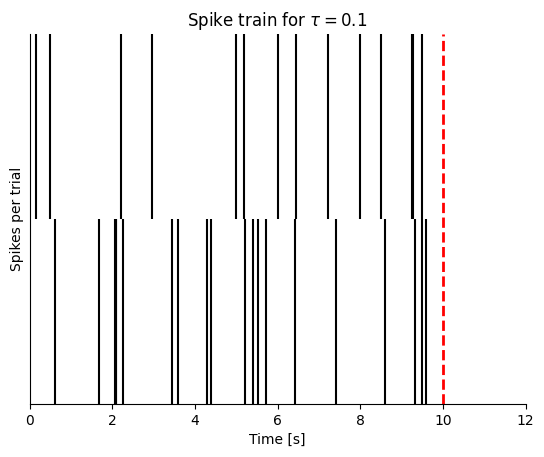

In [4]:
def poisson_spike_train_simple(tau: float, length: float, n_trials: int) -> list[list[float]]:
    """
    Generates a Poisson spike train
    
    Parameters
    ----------
    tau : float
          time constant of the exponential distribution
    length : float
             length of the spike train in seconds
    n_trials : int
               number of trials to generate
    
    Returns
    -------
    spikes : list of lists
             each list contains the spike times for one trial
    
    """
    spikes : list[list[float]] = []
    
    for i in range(n_trials):
        # Generate intial spike
        t_1 = np.random.exponential(tau, 1)
        spikes.append([t_1])

        # Generate the interspike interval
        delta_t = np.random.exponential(tau, 1)
        t_next = spikes[i][-1] + delta_t
        
        while t_next < length:
            # Append the new spike time to the list
            spikes[i].append(t_next)

            # Generate the interspike interval
            delta_t = np.random.exponential(tau, 1)
            t_next = spikes[i][-1] + delta_t
    
    return spikes

# test
spike_times = poisson_spike_train_simple(tau=0.7, length=10., n_trials=2)
ax = raster(spike_times, color='k', t_max=12.)
sns.despine()
plt.axvline(10, color='k', lw=2, ls='--', c="red")
plt.title('Spike train for $\\tau=0.1$')
plt.show()

a) Plot one spike train for each of the following parameter values: $\tau = 1$ sec, $\tau = 0.1$ sec, $\tau = 0.01$ sec  

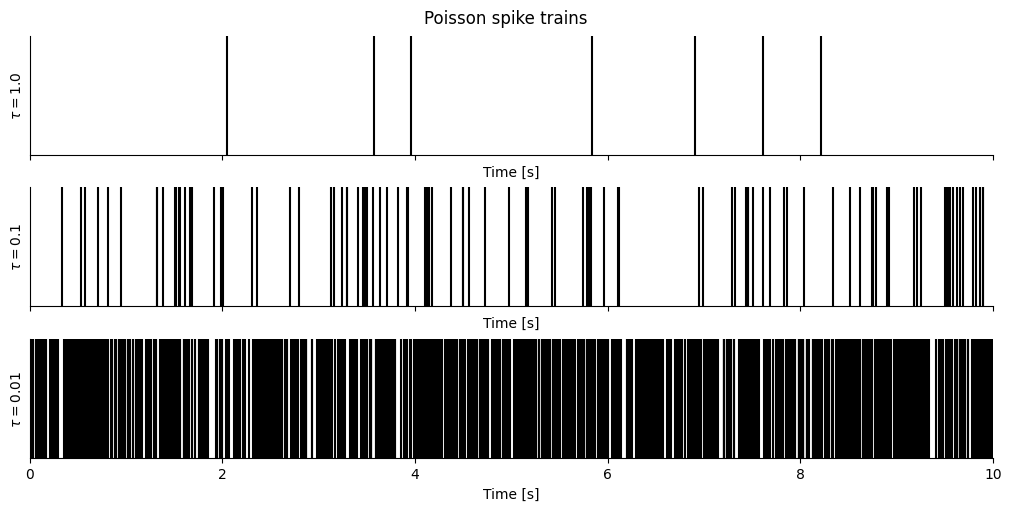

In [5]:
length = 10
taus = [1., 0.1, 0.01]

fig, axs = plt.subplots(nrows=len(taus), figsize=(10, 5), sharex=True, constrained_layout=True)
fig.suptitle("Poisson spike trains")
for tau, ax in zip(taus, axs):
    spike_times = poisson_spike_train_simple(tau=tau, length=length, n_trials=1)
    raster(spike_times, color='k', t_max=length, ax=ax)
    ax.set_ylabel(f'$\\tau={tau}$')
    sns.despine()
plt.show()

b) Simulate 50.000 spike trains for each parameter in a) and compute the total number of spikes (i.e. the “spike count”) for each. Plot a histogram over the spike counts for each of the three conditions, as well as the mean and the variance (not standard deviation).

In [6]:
# Generate spike counts
n_trials = 50000
spike_counts = np.zeros((len(taus), n_trials))
for i, tau in enumerate(taus):
    spike_times_per_trial = poisson_spike_train_simple(tau=tau, length=length, n_trials=n_trials)
    spike_counts[i, :] = np.array([len(spike_times) for spike_times in spike_times_per_trial])

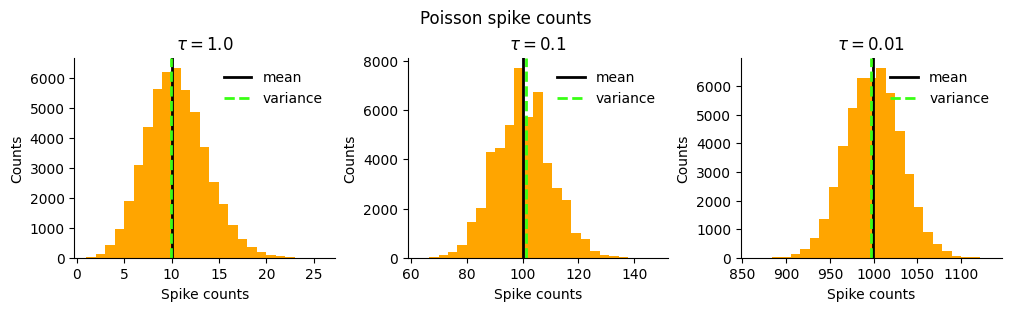

In [7]:
# Plot histogram
fig, axs = plt.subplots(ncols=len(taus), figsize=(10, 3), constrained_layout=True)
fig.suptitle("Poisson spike counts")
for i, (tau, ax) in enumerate(zip(taus, axs)):
    ax.set_title(f'$\\tau={tau}$')
    ax.hist(spike_counts[i, :], bins=25, color='orange', alpha=1)
    ax.set_ylabel('Counts')
    ax.set_xlabel('Spike counts')
    
    mean = np.mean(spike_counts[i, :])
    ax.axvline(mean, color='black', lw=2, ls='-', label="mean")
    
    var = np.var(spike_counts[i, :])
    sns.despine()
    ax.axvline(var, color='#39ff14', lw=2, ls='--', label="variance") # neon green
    ax.legend(frameon=False)

plt.show()

c) Draw 10.000 samples $x_k \in \{0, 1\}$ independently from a Beronulli distribution $P (x_k ) = \lambda^{x_k} (1 − \lambda)^{1−x_k}$ with $k = 1, \ldots , 10.000$ for the following three cases: $\lambda = 0.1$, $\lambda = 0.01$, $\lambda = 0.001$. Plot the random vector $x$ as a spike train for each of the three conditions.

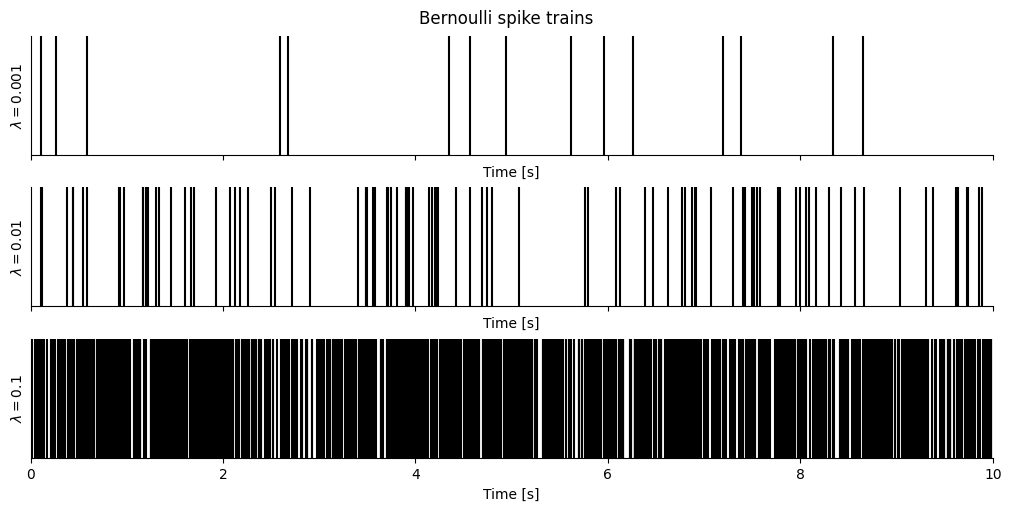

In [8]:
def bernoulli_spike_train(
    p: float, n_samples: int, length: float, n_trials: int = 1
) -> tuple[list[list[float]], list[np.ndarray]]:
    """
    Generates a Bernoulli spike train.

    Parameters
    ----------
    p : float
        Probability of success (spike) for the Bernoulli distribution.
    n_samples : int
        Number of samples (time points) per trial.
    length : float
        Length of the spike train in seconds.
    n_trials : int
        Number of trials to generate.

    Returns
    -------
    tuple
        A tuple containing:
        - spike_trains: list of lists of floats
          Each inner list contains the spike times for one trial.
        - random_vectors: list of numpy arrays
          Each numpy array contains the binary spike train (0s and 1s) for one trial.
    """
    random_vectors : list[np.ndarray] = []
    spike_trains : list[list[float]] = []
    
    spike_times = np.linspace(0, length, n_samples)
    for _ in range(n_trials):
        random_vector = np.random.binomial(1, p, n_samples)
        random_vectors.append(random_vector)

        spike_train = spike_times[random_vector == 1]
        spike_trains.append(spike_train.tolist())

    return spike_trains, random_vectors


# Test the Bernoulli spike train function
lambdas = [0.001, 0.01, 0.1]
n_samples = 10000

fig, axs = plt.subplots(
    nrows=len(lambdas), figsize=(10, 5), sharex=True, constrained_layout=True
)
fig.suptitle("Bernoulli spike trains")
for lam, ax in zip(lambdas, axs):
    spike_trains, _ = bernoulli_spike_train(
        lam, n_samples, length, n_trials=1
    )
    raster(spike_trains, color="k", t_max=length, ax=ax)
    ax.set_ylabel(f"$\\lambda={lam}$")
    sns.despine()
plt.show()

d) Simulate 50.000 spike trains for each parameter in c) and compute the total number of spikes (i.e. the “spike count”) for each. Plot a histogram over the spike counts for each of the three conditions, as well as the mean and the variance.

How do the results differ from those b)?

In [9]:
# Generate spike counts
n_trials = 50000
spike_counts_bernoulli = np.zeros((len(lambdas), n_trials))
for i, lam in enumerate(lambdas):
    spike_times_per_trial, _ = bernoulli_spike_train(lam, n_samples, length, n_trials=n_trials)
    spike_counts_bernoulli[i, :] = np.array([len(spike_times) for spike_times in spike_times_per_trial])

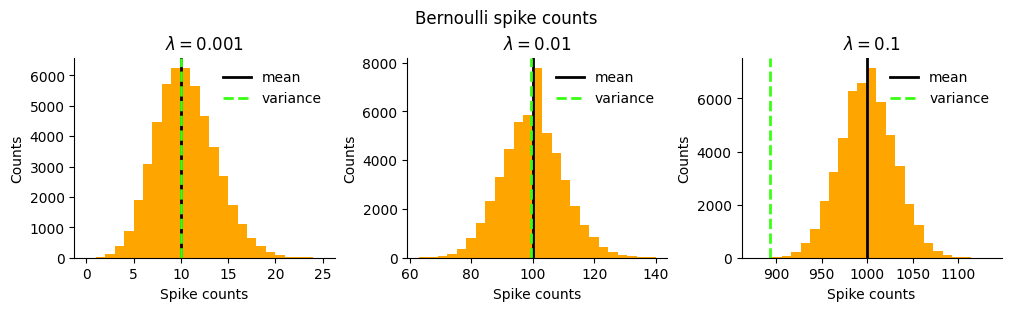

In [10]:
# Plot histogram
fig, axs = plt.subplots(ncols=len(taus), figsize=(10, 3), constrained_layout=True)
fig.suptitle("Bernoulli spike counts")
for i, (lamb, ax) in enumerate(zip(lambdas, axs)):
    ax.set_title(f'$\\lambda={lamb}$')
    ax.hist(spike_counts_bernoulli[i, :], bins=25, color='orange', alpha=1)
    ax.set_ylabel('Counts')
    ax.set_xlabel('Spike counts')
    
    mean = np.mean(spike_counts_bernoulli[i, :])
    ax.axvline(mean, color='black', lw=2, ls='-', label="mean")
    
    var = np.var(spike_counts_bernoulli[i, :])

    ax.axvline(var, color='#39ff14', lw=2, ls='--', label="variance") # neon green
    sns.despine()
    ax.legend(frameon=False)

plt.show()

**Answer** The histograms look very similar, when comparing small $\lambda$ with high $\tau$, e.g. $\lambda = 0.001$ shows the same mean, variance and shape as the result for $\tau = 1.0$. The same holds for $\lambda = 0.01$ and $\tau = 0.1$. The only exception is the variance for large $\lambda = 0.1$, which is clearly smaller than the mean, and thus differs from the result for $\tau = 0.01$. 

For the Bernoulli case:
$$
\mathbb{E}[N] = n_{\text{samples}} \, p, \quad \mathrm{Var}[N] = n_{\text{samples}} \, p (1 - p).
$$

Hence, here $\mathrm{Var}[N] = \mathbb{E}[N](1-p)$, which is slightly less than the mean.

By contrast, for the Poisson case we had $\mathrm{Var}[N] = \mathbb{E}[N]$.

The effect is that the Bernoulli-sum histograms are a bit narrower relative to their mean than the Poisson histograms, especially for larger $p$, because the $(1-p)$ factor reduces the variance.

e) The cases in which the distributions in b) and d) match and disagree with each other is related to the limit cases discussed in the lecture. Under which circumstance do the Binomial distribution and the Poisson distribution match each other? Under these assumptions, proof, by taking the limit, that the probability functions are the same. (2 points)

*Hint: Relate $\lambda$, $p$, and $n$ to each other. Take the appropriate limit* $$\lim_{\substack{n \to\infty \\ p\to 0}}$$
*and show that $P_{Bernoulli}(X=s)$ in the limit is the same as $P_{Poisson}(X=s)$.*

**Answer** Under $n \to \infty$ and $p \to 0$, while $n \cdot p = const.$ Previously in d) $\lambda = p$. So for previously used $n = 10.000$ number of time points, for too large $\lambda > 0.01$ (as defined before e)) we observed differences in the variance of the Binomial distribution for counts of the Bernoulli spike trains and the Poisson distribution for counts of the Poisson spike trains.

**Proof**

The probability mass function of the Binomial distribution is given by:
\begin{equation*}
P_{Binomial}(X = s) = \binom{n}{s} p^s (1 - p)^{n - s}
\end{equation*}

For $n \to \infty$ and $p \to 0$, such that $n \cdot p = \lambda$, we obtain:
\begin{equation*}
\binom{n}{s} = \frac{n!}{s!(n-s)!} \to \frac{n^s}{s!}
\end{equation*}
because for $n \to \infty$ with constant $s$
\begin{equation*}
\frac{n!}{(n-s)!} \cdot \frac{1}{n^s} = \frac{n \cdot (n-1) \cdots (n-(s-1))}{n \cdot n \cdots n} = 1 \cdot (1-\frac{1}{n}) \cdots (1-\frac{s-1}{n}) \to 1 \cdot 1 \cdots 1 = 1.
\end{equation*}
We also obtain:
\begin{equation*}
    (1 - p)^{n-s} \to e^{-np}
\end{equation*}
because for $p \to 0$ and constant s $(1-p)^{-s} \to 1$. And because from the limit definition of the exponential function $e^x = \lim_{k \to\infty} (1 + \frac{x}{k})^k$, for $n \to \infty$ and constant $np$ we get
\begin{equation*}
(1 - p)^{n} = (1 + \frac{-np}{n})^{n} \to e^{-np}.
\end{equation*}

Substituting these approximations, therefore:
\begin{equation*}
P_{Binomial}(X = s) \approx \frac{n^s}{s!} p^s e^{-np} = \frac{(np)^s}{s!} e^{-np} = \frac{\lambda^s}{s!} e^{-\lambda},
\end{equation*}

which is exactly the probability mass function of the Poisson distribution:
\begin{equation*}
P_{Poisson}(X = s) = \frac{\lambda^s}{s!} e^{-\lambda}.
\end{equation*}

Thus, in the limit $n \to \infty$ and $p \to 0$, with $n \cdot p = \lambda = const.$, the Binomial distribution converges to the Poisson distribution.

## Exercise 2
2) Compute the mean and variance of the Poisson distribution with parameter $\lambda$ (first try yourself) (3 points)

**Answer**

\begin{equation*}
P(x = k) = \text{Poisson}(k \  ; \lambda) = \frac{\lambda^{k} \cdot e^{-\lambda}}{k\,!}
\end{equation*} 
Mean: with $k' = k -1$
\begin{equation*}
\begin{split}
E(x) &= \sum_{k=0}^{\infty} k \cdot P(x = k) \\
&= \sum_{k=0}^{\infty} k \cdot \frac{\lambda^{k} \cdot e^{-\lambda}}{k\,!} \\
&= e^{-\lambda} \sum_{k=0}^{\infty} k \cdot \frac{\lambda^{k}}{k\,!} \\
&= e^{-\lambda} \left( 0 + \sum_{k=1}^{\infty} k \cdot \frac{\lambda^{k}}{k\,!} \right) \\ 
&= e^{-\lambda} \sum_{k=1}^{\infty} \frac{\lambda^{k}}{(k-1)\,!} \\
&= e^{-\lambda} \lambda \sum_{k=1}^{\infty} \frac{\lambda^{k-1}}{(k-1)\,!} \\
&= e^{-\lambda} \lambda \sum_{k'=1}^{\infty} \frac{\lambda^{k'}}{k'\,!} \\
&= e^{-\lambda} \lambda e^{\lambda} \\
&= \lambda.
\end{split}
\end{equation*}


Variance: Using the results and caclulation steps from above (and again $k' = k -1$, i.e. $k = k' + 1$)
\begin{equation*}
\begin{split}
Var(x) &= E(x^2) - E(x)^2 \\
&= \left( \sum_{k=0}^{\infty} k^2 \cdot \frac{\lambda^{k} \cdot e^{-\lambda}}{k\,!} \right) - \lambda^2 = \left( e^{-\lambda} \sum_{k=1}^{\infty} k^2 \cdot \frac{\lambda^{k}}{k\,!} \right) - \lambda^2 \\ 
&= \left( e^{-\lambda} \lambda \sum_{k=1}^{\infty} k \cdot \frac{\lambda^{k-1}}{(k-1)\,!} \right) - \lambda^2 \\
&= \left( e^{-\lambda} \lambda \sum_{k'=0}^{\infty} (k'+1) \cdot \frac{\lambda^{k'}}{k'\,!} \right) - \lambda^2 \\ 
&= \left[ e^{-\lambda} \lambda \left(\sum_{k'=0}^{\infty} k' \cdot \frac{\lambda^{k'}}{k'\,!}\right) + \left(\sum_{k'=0}^{\infty} 1 \cdot \frac{\lambda^{k'}}{k'\,!} \right) \right] - \lambda^2 \\
&= e^{-\lambda} \lambda \left(\lambda e^{\lambda} + e^{\lambda} \right) - \lambda^2 \\
&= \lambda (\lambda + 1) - \lambda^2 \\
&= \lambda = E(x)
\end{split}
\end{equation*}



## Exercise 3
3) Show that the sum of two independent Poisson random variables of parameters $\lambda$ and $\mu$ is again Poisson with
parameter $\lambda + \mu $. (2 points)

If $X \sim \text{Poisson}(\lambda) $ and $Y \sim \text{Poisson}(\mu)$, we have
\begin{equation*}
\begin{split}
P(k = X + Y) & = \sum_{i=0}^{k} P(X = i, Y = k - i) \\
& = \sum_{i=0}^{k} P(X = i) \cdot P(Y = k - i) \\
&= \sum_{i=0}^{k} \frac{\lambda^{i} \cdot e^{-\lambda}}{i\,!} \cdot \frac{\mu^{k-i} \cdot e^{-\mu}}{(k-i)\,!} \\
&= e^{-(\lambda + \mu)} \sum_{i=0}^{k} \frac{1}{i\,! \cdot (k-i)\,!} \cdot \lambda^{i} \cdot \mu^{k-i} \\
&= e^{-(\lambda + \mu)} \frac{1}{k\,!} \sum_{i=0}^{k} \binom{k}{i} \cdot \lambda^{i} \cdot \mu^{k-i} \\
&= e^{-(\lambda + \mu)} \frac{(\mu + \lambda)^k}{k\,!} \text{(by the binomial theorem)} \\
&= \text{Poisson}(\lambda + \mu)
\end{split}
\end{equation*}